# IC3392: QC of new pyqz, NebulaBayes, and JY22/Peng2026 products

**Date:** 2026-08-24  
**Scope:** one-galaxy test-run QC of the downloaded `IC3392_gas_bin_maps_further.fits` and `IC3392.log`. This notebook is read-only with respect to the science product and does not rerun or modify `SFR+Z.py`.

## Questions

1. Does pyqz reproduce the spatial range and ordering of the primary O3N2-C20 reference?
2. Is the blocky NebulaBayes map evidence that the interpolation grid is too sparse, or is it mainly the stored marginal-peak estimator, spatial binning, and boundary behavior?
3. Is the high JY22/Peng2026 abundance a numerical/plumbing error, a known calibration zero-point difference, or evidence that IC3392 is not well described by the adopted model likelihood?
4. Do the auxiliary properties and QC maps (ionisation parameter, pressure, uncertainties, fit statistics, edge flags, and off-grid fractions) reveal issues hidden by the O/H maps?

## Comparison hierarchy and guards

- **Primary internal reference:** O3N2-C20, as requested.
- **Secondary references:** D16, PG16, and O3N2-M13.
- O3N2-C20 is a comparison reference, not ground truth; different abundance scales can have real zero-point and slope differences.
- The O3N2 calibration used in Peng et al. (2026), equation `8.533 - 0.214 O3N2`, is **O3N2-M13**, not C20. Therefore the paper's JY22–O3N2 discussion must first be compared with the local M13 product, then translated to C20 using the measured IC3392 C20–M13 offset.
- The pipeline fits once per spatial `BIN_ID` and broadcasts the result to all pixels in that bin. Primary statistics below therefore use **one row per bin**. Pixel maps are retained only to inspect spatial structure.
- `VALID=1` means a finite stored estimate; it does not guarantee a clean flag, an interior posterior, or an acceptable fit statistic.

Primary method references: [Peng et al. 2026](https://arxiv.org/abs/2608.20239), [Ji & Yan 2022](https://arxiv.org/abs/2110.00612), and [Thomas et al. 2018 / NebulaBayes](https://arxiv.org/abs/1803.00740).

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import linregress, spearmanr

from model_grid_diagnostics import (
    JY22Grid,
    MODEL_LINE_BASES,
    build_jy22_ratio_spectra,
    extract_unique_bin_spectra,
    infer_jy22_posterior,
    load_jy22_grid,
)

ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
FITS_PATH = ROOT / "v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps_further.fits"
LOG_PATH = ROOT / "v3tk_v7.6.8/sfr_logs/IC3392.log"
GRID_PATH = ROOT / "Peng2026/photoionization_models/photoionization_grid_interpolated.fits"
GRID_README_PATH = ROOT / "Peng2026/photoionization_models/readme.md"

for path in (FITS_PATH, LOG_PATH, GRID_PATH, GRID_README_PATH):
    assert path.is_file(), f"Missing required input: {path}"

METHODS = {
    "O3N2-C20": "O_H_O3N2_C20_HII",
    "D16": "O_H_D16_HII",
    "PG16": "O_H_PG16_HII",
    "O3N2-M13": "O_H_O3N2_M13_HII",
    "pyqz": "O_H_PYQZ_HII",
    "NebulaBayes": "O_H_NEBULABAYES_HII",
    "JY22/Peng2026": "O_H_JY22_HII",
}
NEW_METHODS = ("pyqz", "NebulaBayes", "JY22/Peng2026")

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print(f"FITS: {FITS_PATH}")
print(f"Log:  {LOG_PATH}")
print(f"Grid: {GRID_PATH}")

FITS: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps_further.fits
Log:  /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/sfr_logs/IC3392.log
Grid: /Users/Igniz/Desktop/ICRAR/further/Peng2026/photoionization_models/photoionization_grid_interpolated.fits


## 1. Load the live product and establish provenance

Only explicitly named HDUs are copied into memory. The contiguous new-diagnostic block is also inventoried from the live file so that conclusions are tied to the actual downloaded artifact rather than the screenshot.

In [2]:
AUX_HDUS = (
    "O_H_PYQZ_HII_ERR",
    "LOG_Q_PYQZ_HII",
    "LOG_Q_PYQZ_HII_ERR",
    "LOG_U_PYQZ_HII",
    "LOG_U_PYQZ_HII_ERR",
    "PYQZ_FLAG_HII",
    "PYQZ_RS_OFFGRID_HII",
    "PYQZ_VALID_HII",
    "O_H_NEBULABAYES_HII_CI68_LOW",
    "O_H_NEBULABAYES_HII_CI68_HIGH",
    "LOG_U_NEBULABAYES_HII",
    "LOG_U_NEBULABAYES_HII_CI68_LOW",
    "LOG_U_NEBULABAYES_HII_CI68_HIGH",
    "LOG_PK_NEBULABAYES_HII",
    "LOG_PK_NEBULABAYES_HII_CI68_LOW",
    "LOG_PK_NEBULABAYES_HII_CI68_HIGH",
    "NB_CHI2_RED_HII",
    "NB_NLOCALMAX_HII",
    "NB_FLAG_HII",
    "NB_VALID_HII",
    "O_H_JY22_HII_16",
    "O_H_JY22_HII_84",
    "LOG_U_JY22_HII",
    "LOG_U_JY22_HII_16",
    "LOG_U_JY22_HII_84",
    "JY22_CHI2_MIN_HII",
    "JY22_FLAG_HII",
    "JY22_VALID_HII",
)

requested_hdus = tuple(dict.fromkeys(("BIN_ID", *METHODS.values(), *AUX_HDUS)))
maps = {}
inventory_rows = []

with fits.open(FITS_PATH, memmap=True) as hdul:
    available = {hdu.name for hdu in hdul}
    missing = sorted(set(requested_hdus) - available)
    assert not missing, f"Required HDUs are absent: {missing}"
    for name in requested_hdus:
        maps[name] = np.array(hdul[name].data, dtype=np.float64, copy=True)
    for index in range(278, 340):
        hdu = hdul[index]
        inventory_rows.append(
            {
                "index": index,
                "name": hdu.name,
                "shape": None if hdu.data is None else tuple(hdu.data.shape),
                "BUNIT": hdu.header.get("BUNIT", ""),
                "comment": hdu.header.get("COMMENT", ""),
            }
        )
    header = hdul[0].header.copy()
    n_hdus = len(hdul)

inventory = pd.DataFrame(inventory_rows)
provenance_keys = (
    "DUSTLAW",
    "PYQZVER", "PYQZGRD", "PYQZDG", "PYQZPK", "PYQZSTR", "PYQZKAP",
    "PYQZSMP", "PYQZSRS", "PYQZKDE", "PYQZSED",
    "NBAYVER", "NBGRID", "NBSHAPE", "NBORDER", "NBGRERR", "NBPRIOR",
    "NBDERED", "NBNORM",
    "JY22EN", "JY22GRID", "JY22SHA", "JY22REF", "JY22PRIR",
    "JY22UMIN", "JY22UMAX", "JY22UELO", "JY22UEHI", "JY22SOL",
    "JY22RAT", "JY22COV", "JY22EINF", "JY22BD",
)
provenance = pd.DataFrame(
    [(key, header[key], header.comments[key]) for key in provenance_keys if key in header],
    columns=("keyword", "value", "comment"),
)

print(f"Loaded {len(requested_hdus)} maps from a {n_hdus}-HDU FITS file; image shape={maps['BIN_ID'].shape}.")
display(provenance)
display(inventory)

Loaded 36 maps from a 395-HDU FITS file; image shape=(438, 437).


,keyword,value,comment
0,DUSTLAW,calzetti,
1,PYQZVER,0.8.4.0,
2,PYQZGRD,MAPPINGS V 5.0.16,
3,PYQZDG,[NII]/[SII]+;[OIII]/[SII]+,
4,PYQZPK,5.0,Fixed log10(P/k / (K cm-3))
5,PYQZSTR,pp,
6,PYQZKAP,inf,Kappa electron distribution
7,PYQZSMP,2,
8,PYQZSRS,800,
9,PYQZKDE,multiv,


,index,name,shape,BUNIT,comment
0,278,O_H_PYQZ_HII,"(438, 437)",1,"[12+log(O/H), pyqz combined multivariate-KDE e..."
1,279,O_H_PYQZ_SF,"(438, 437)",1,"[12+log(O/H), pyqz combined multivariate-KDE e..."
2,280,O_H_PYQZ_HII_ERR,"(438, 437)",1,[pyqz uncertainty: maximum half-extent of peak...
3,281,O_H_PYQZ_SF_ERR,"(438, 437)",1,[pyqz uncertainty: maximum half-extent of peak...
4,282,LOG_Q_PYQZ_HII,"(438, 437)",1,"[log10(q / (cm s-1)), pyqz combined multivaria..."
...,...,...,...,...,...
57,335,JY22_CHI2_MIN_SF,"(438, 437)",1,[Minimum JY22 chi-square using full N2/S2/R3 c...
58,336,JY22_FLAG_HII,"(438, 437)",1,"[JY22 QC bits: 1=O/H edge, 2=logU edge, 4=post..."
59,337,JY22_FLAG_SF,"(438, 437)",1,"[JY22 QC bits: 1=O/H edge, 2=logU edge, 4=post..."
60,338,JY22_VALID_HII,"(438, 437)",1,[1=all JY22 summaries and chi2 finite; 0=inval...


## 2. Use one representative row per fitted HII-region bin

The HII inference aperture is defined here by the finite JY22 product mask because all 2,404 eligible HII bins received a finite JY22 result. Method-specific finite masks are applied later for each comparison. Within-bin constancy is checked before any bin-weighted summary is accepted.

In [3]:
bin_id_map = maps["BIN_ID"]
hii_pixel_mask = (
    np.isfinite(bin_id_map)
    & (maps["JY22_VALID_HII"] == 1)
)
eligible_flat = np.flatnonzero(hii_pixel_mask.ravel())
bin_ids, first_positions = np.unique(
    bin_id_map.ravel()[eligible_flat], return_index=True
)
representative_flat = eligible_flat[first_positions]

bin_df = pd.DataFrame({"BIN_ID": bin_ids})
for name in requested_hdus:
    if name != "BIN_ID":
        bin_df[name] = maps[name].ravel()[representative_flat]

within_bin_checks = []
for name in (*METHODS.values(), *AUX_HDUS):
    image = maps[name]
    max_ptp = 0.0
    for bin_id in bin_ids:
        values = image[hii_pixel_mask & (bin_id_map == bin_id)]
        finite = values[np.isfinite(values)]
        if finite.size:
            max_ptp = max(max_ptp, float(np.ptp(finite)))
    within_bin_checks.append((name, max_ptp))

max_within_bin_ptp = max(value for _, value in within_bin_checks)
assert max_within_bin_ptp == 0.0, "At least one inferred output varies within BIN_ID"

spatial_union = np.zeros_like(hii_pixel_mask, dtype=bool)
for name in METHODS.values():
    spatial_union |= np.isfinite(maps[name])
ys, xs = np.where(spatial_union)
y_slice = slice(int(ys.min()), int(ys.max()) + 1)
x_slice = slice(int(xs.min()), int(xs.max()) + 1)
map_extent = (xs.min() - 0.5, xs.max() + 0.5, ys.min() - 0.5, ys.max() + 0.5)

print(f"HII aperture: {hii_pixel_mask.sum():,} pixels in {len(bin_ids):,} unique spatial bins")
print(f"Maximum within-bin peak-to-peak variation across checked products: {max_within_bin_ptp:g}")
print(f"Map crop: x={x_slice.start}:{x_slice.stop}, y={y_slice.start}:{y_slice.stop}")

HII aperture: 14,845 pixels in 2,404 unique spatial bins
Maximum within-bin peak-to-peak variation across checked products: 0
Map crop: x=144:308, y=72:322


## 3. Metallicities: ranges, pairwise offsets, and response to C20

The percentile span measures the **distributional range**. The Spearman coefficient and fitted response slope measure whether a diagnostic preserves the **spatial ordering and contrast** of C20. These are different questions: a method can have a broad distribution while varying in a pattern unrelated to C20.

In [4]:
UNCERTAINTY_MAPS = {
    "pyqz": ("O_H_PYQZ_HII_ERR", None),
    "NebulaBayes": (
        "O_H_NEBULABAYES_HII_CI68_LOW",
        "O_H_NEBULABAYES_HII_CI68_HIGH",
    ),
    "JY22/Peng2026": ("O_H_JY22_HII_16", "O_H_JY22_HII_84"),
}

summary_rows = []
for label, hdu_name in METHODS.items():
    values = bin_df[hdu_name].to_numpy(float)
    finite = values[np.isfinite(values)]
    p02, p16, p50, p84, p98 = np.percentile(finite, [2, 16, 50, 84, 98])
    uncertainty = np.nan
    if label in UNCERTAINTY_MAPS:
        low_name, high_name = UNCERTAINTY_MAPS[label]
        if high_name is None:
            uncertainty = np.nanmedian(bin_df[low_name])
        else:
            uncertainty = np.nanmedian(
                0.5 * (bin_df[high_name] - bin_df[low_name])
            )
    summary_rows.append(
        {
            "method": label,
            "n_bin": finite.size,
            "p02": p02,
            "p16": p16,
            "median": p50,
            "p84": p84,
            "p98": p98,
            "p98-p02": p98 - p02,
            "unique": np.unique(finite).size,
            "median half-interval/error": uncertainty,
        }
    )
metal_summary = pd.DataFrame(summary_rows).set_index("method")

reference = bin_df[METHODS["O3N2-C20"]].to_numpy(float)
comparison_rows = []
for label, hdu_name in METHODS.items():
    if label == "O3N2-C20":
        continue
    candidate = bin_df[hdu_name].to_numpy(float)
    matched = np.isfinite(reference) & np.isfinite(candidate)
    x = reference[matched]
    y = candidate[matched]
    delta = y - x
    regression = linregress(x, y)
    comparison_rows.append(
        {
            "method minus C20": label,
            "n_matched": matched.sum(),
            "delta_p16": np.percentile(delta, 16),
            "delta_median": np.median(delta),
            "delta_p84": np.percentile(delta, 84),
            "Spearman_rho": spearmanr(x, y).statistic,
            "OLS_slope": regression.slope,
            "OLS_intercept": regression.intercept,
        }
    )
comparison_to_c20 = pd.DataFrame(comparison_rows).set_index("method minus C20")

pair_specs = (
    ("C20 - M13", "O3N2-C20", "O3N2-M13"),
    ("JY22 - M13", "JY22/Peng2026", "O3N2-M13"),
    ("JY22 - C20", "JY22/Peng2026", "O3N2-C20"),
)
pair_rows = []
for comparison, left, right in pair_specs:
    a = bin_df[METHODS[left]].to_numpy(float)
    b = bin_df[METHODS[right]].to_numpy(float)
    matched = np.isfinite(a) & np.isfinite(b)
    delta = a[matched] - b[matched]
    pair_rows.append(
        {
            "comparison": comparison,
            "n_matched": matched.sum(),
            "p16": np.percentile(delta, 16),
            "median": np.median(delta),
            "p84": np.percentile(delta, 84),
        }
    )
pair_offsets = pd.DataFrame(pair_rows).set_index("comparison")

display(metal_summary.round(4))
display(comparison_to_c20.round(4))
display(pair_offsets.round(4))

c20_span = metal_summary.loc["O3N2-C20", "p98-p02"]
jy22_span = metal_summary.loc["JY22/Peng2026", "p98-p02"]
display(
    Markdown(
        f"**Dynamic-range check:** JY22 p98–p02 = **{jy22_span:.3f} dex** and "
        f"C20 p98–p02 = **{c20_span:.3f} dex**. Thus JY22 is not narrower by "
        "this robust distributional measure; the concern is instead its weak spatial "
        f"response to C20 (slope {comparison_to_c20.loc['JY22/Peng2026', 'OLS_slope']:.2f}, "
        f"Spearman ρ={comparison_to_c20.loc['JY22/Peng2026', 'Spearman_rho']:.2f})."
    )
)

,n_bin,p02,p16,median,p84,p98,p98-p02,unique,median half-interval/error
method,,,,,,,,,
O3N2-C20,2403,8.7159,8.7468,8.7765,8.8120,8.8560,0.1401,2403,NaN
D16,2404,8.6884,8.7405,8.7931,8.8611,8.9362,0.2478,2404,NaN
PG16,2404,8.4950,8.5197,8.5499,8.5902,8.6238,0.1287,2404,NaN
O3N2-M13,2401,8.4996,8.5323,8.5646,8.6044,8.6546,0.1550,2401,NaN
pyqz,2394,8.6390,8.6917,8.7391,8.7863,8.8294,0.1904,2394,0.0452
NebulaBayes,2404,8.6692,8.7397,8.8949,8.9513,9.0078,0.3386,32,0.0635
JY22/Peng2026,2404,8.9591,9.0268,9.0870,9.1071,9.1803,0.2212,2255,0.0158


,n_matched,delta_p16,delta_median,delta_p84,Spearman_rho,OLS_slope,OLS_intercept
method minus C20,,,,,,,
D16,2403,-0.0550,0.0137,0.1009,-0.2395,-0.3767,12.1058
PG16,2403,-0.2796,-0.2299,-0.1681,-0.2396,-0.2106,10.4028
O3N2-M13,2401,-0.2144,-0.2118,-0.2075,1.0000,1.1127,-1.2003
pyqz,2394,-0.0791,-0.0419,0.0006,0.5325,0.8065,1.6586
NebulaBayes,2403,-0.0166,0.1063,0.1574,0.6787,1.8183,-7.1027
JY22/Peng2026,2403,0.2414,0.3044,0.3460,0.0903,0.0687,8.4687


,n_matched,p16,median,p84
comparison,,,,
C20 - M13,2401,0.2075,0.2118,0.2144
JY22 - M13,2401,0.4489,0.5166,0.5594
JY22 - C20,2403,0.2414,0.3044,0.3460


**Dynamic-range check:** JY22 p98–p02 = **0.221 dex** and C20 p98–p02 = **0.140 dex**. Thus JY22 is not narrower by this robust distributional measure; the concern is instead its weak spatial response to C20 (slope 0.07, Spearman ρ=0.09).

### Common-scale maps

All panels below use one absolute abundance scale. This removes the independent colour-bar scaling in the CARTA screenshot, which otherwise makes visual range comparisons unreliable.

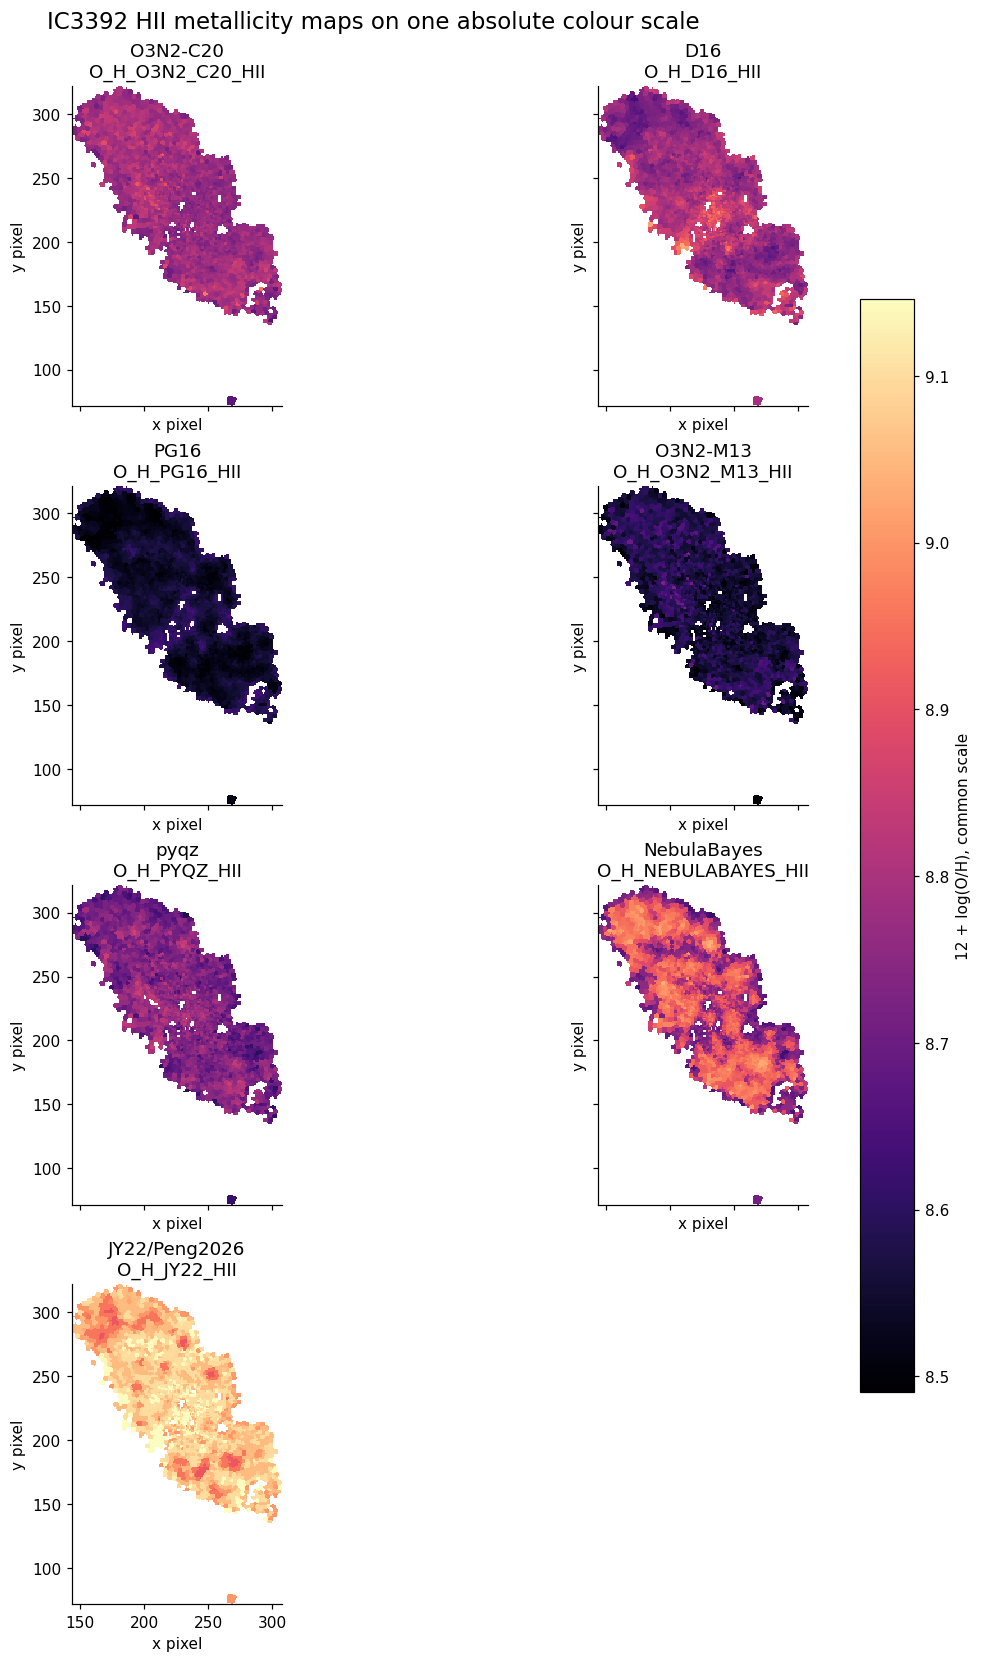

In [5]:
all_metal_values = np.concatenate(
    [maps[name][np.isfinite(maps[name])] for name in METHODS.values()]
)
common_vmin, common_vmax = np.percentile(all_metal_values, [0.5, 99.5])

fig, axes = plt.subplots(4, 2, figsize=(11, 15), constrained_layout=True, sharex=True, sharey=True)
axes = axes.ravel()
image = None
for ax, (label, hdu_name) in zip(axes, METHODS.items()):
    image = ax.imshow(
        maps[hdu_name][y_slice, x_slice],
        origin="lower",
        extent=map_extent,
        cmap="magma",
        vmin=common_vmin,
        vmax=common_vmax,
        interpolation="nearest",
    )
    ax.set_title(f"{label}\n{hdu_name}")
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
axes[-1].axis("off")
fig.colorbar(image, ax=axes.tolist(), shrink=0.72, label="12 + log(O/H), common scale")
fig.suptitle("IC3392 HII metallicity maps on one absolute colour scale", fontsize=15)
# fig.savefig(ROOT / "20260824_IC3392_metallicity_common_scale.png", bbox_inches="tight")
plt.show()

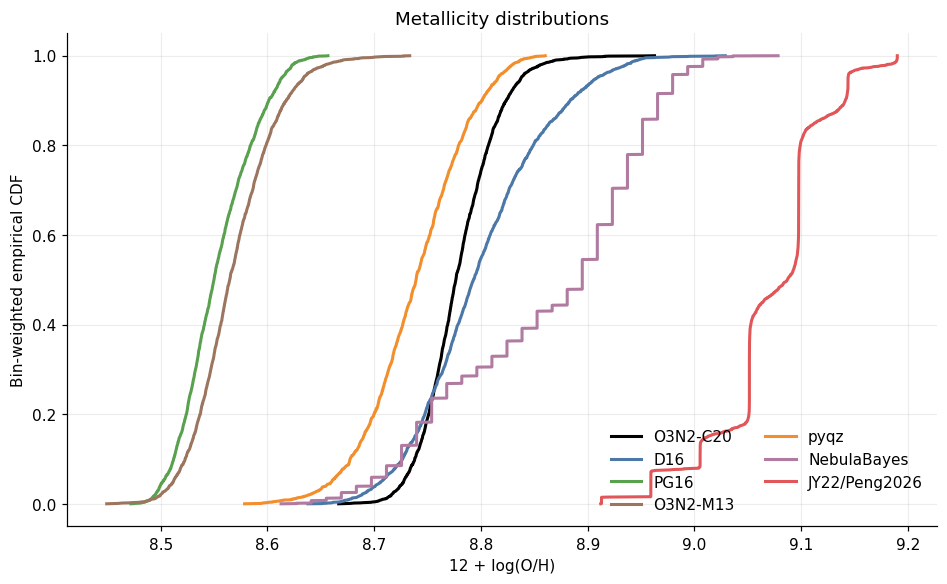

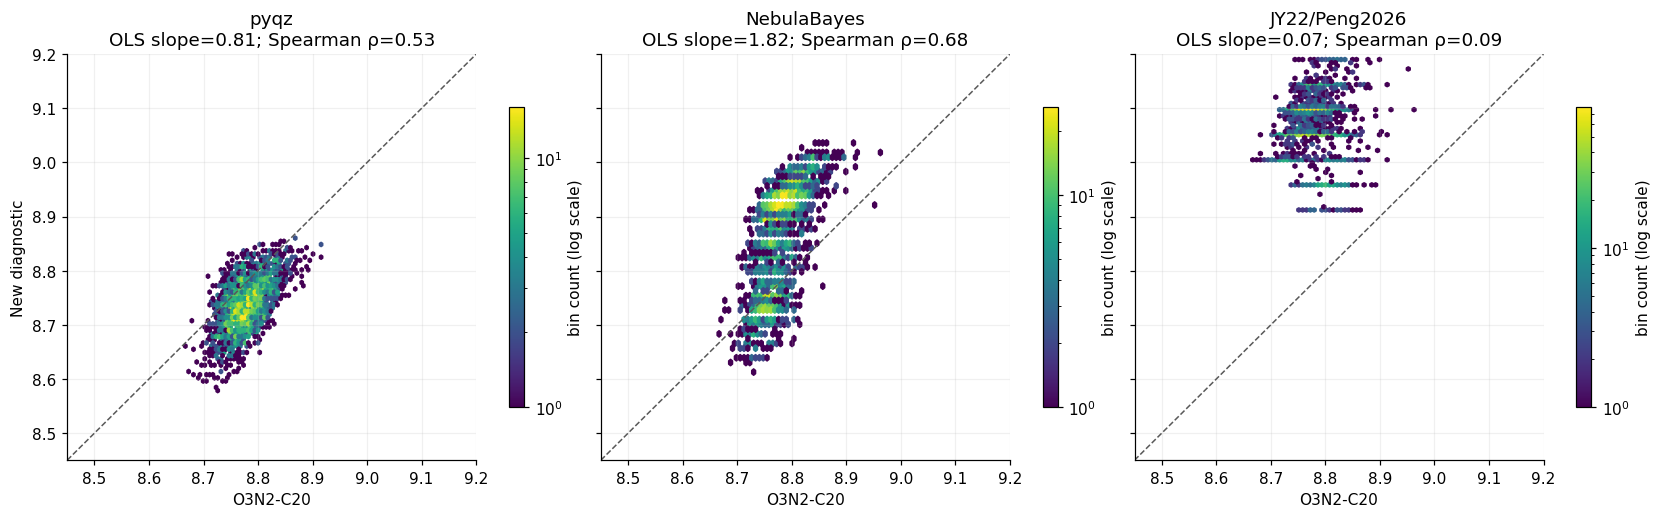

In [6]:
colors = {
    "O3N2-C20": "black",
    "D16": "#4C78A8",
    "PG16": "#59A14F",
    "O3N2-M13": "#9C755F",
    "pyqz": "#F28E2B",
    "NebulaBayes": "#B07AA1",
    "JY22/Peng2026": "#E15759",
}

fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
for label, hdu_name in METHODS.items():
    values = np.sort(bin_df[hdu_name].dropna().to_numpy(float))
    cdf = (np.arange(values.size) + 0.5) / values.size
    ax.plot(values, cdf, lw=2, label=label, color=colors[label])
ax.set(xlabel="12 + log(O/H)", ylabel="Bin-weighted empirical CDF", title="Metallicity distributions")
ax.grid(alpha=0.22)
ax.legend(ncol=2, frameon=False)
# fig.savefig(ROOT / "20260824_IC3392_metallicity_cdf.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True, sharex=True, sharey=True)
plot_limits = (min(common_vmin, 8.45), max(common_vmax, 9.20))
for ax, label in zip(axes, NEW_METHODS):
    candidate = bin_df[METHODS[label]].to_numpy(float)
    matched = np.isfinite(reference) & np.isfinite(candidate)
    hb = ax.hexbin(reference[matched], candidate[matched], gridsize=42, bins="log", mincnt=1, cmap="viridis")
    ax.plot(plot_limits, plot_limits, "--", color="0.35", lw=1, label="1:1")
    slope = comparison_to_c20.loc[label, "OLS_slope"]
    rho = comparison_to_c20.loc[label, "Spearman_rho"]
    ax.set_title(f"{label}\nOLS slope={slope:.2f}; Spearman ρ={rho:.2f}")
    ax.set_xlabel("O3N2-C20")
    ax.set_xlim(plot_limits)
    ax.set_ylim(plot_limits)
    ax.grid(alpha=0.18)
    fig.colorbar(hb, ax=ax, shrink=0.74, label="bin count (log scale)")
axes[0].set_ylabel("New diagnostic")
# fig.savefig(ROOT / "20260824_IC3392_new_metallicity_vs_C20.png", bbox_inches="tight")
plt.show()

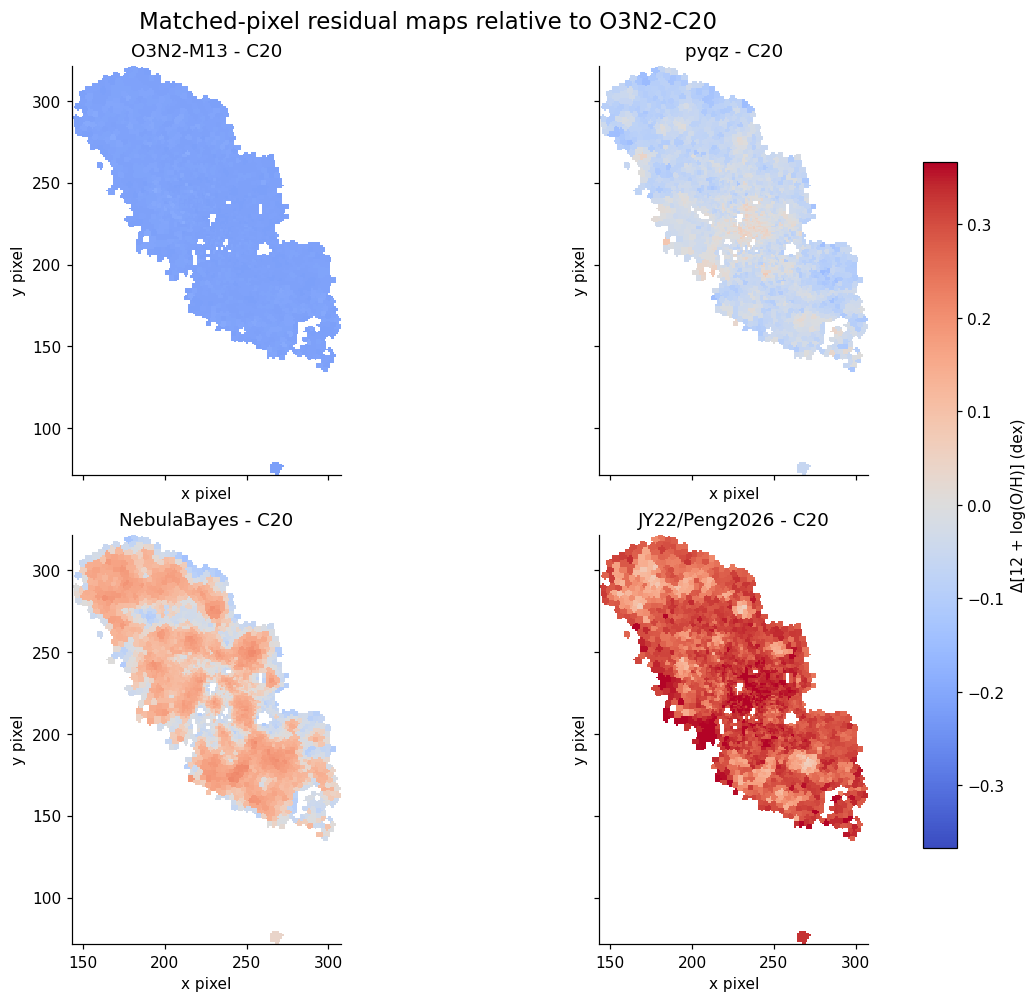

In [7]:
difference_specs = (
    ("O3N2-M13 - C20", "O3N2-M13"),
    ("pyqz - C20", "pyqz"),
    ("NebulaBayes - C20", "NebulaBayes"),
    ("JY22/Peng2026 - C20", "JY22/Peng2026"),
)
reference_map = maps[METHODS["O3N2-C20"]]
differences = [maps[METHODS[label]] - reference_map for _, label in difference_specs]
finite_abs = np.concatenate([np.abs(x[np.isfinite(x)]) for x in differences])
difference_limit = np.percentile(finite_abs, 99)
norm = TwoSlopeNorm(vmin=-difference_limit, vcenter=0.0, vmax=difference_limit)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True, sharex=True, sharey=True)
for ax, (title, _), difference in zip(axes.ravel(), difference_specs, differences):
    image = ax.imshow(
        difference[y_slice, x_slice], origin="lower", extent=map_extent,
        cmap="coolwarm", norm=norm, interpolation="nearest"
    )
    ax.set_title(title)
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.78, label="Δ[12 + log(O/H)] (dex)")
fig.suptitle("Matched-pixel residual maps relative to O3N2-C20", fontsize=15)
# fig.savefig(ROOT / "20260824_IC3392_metallicity_residual_maps.png", bbox_inches="tight")
plt.show()

## 4. Numerical resolution, uncertainties, flags, and auxiliary properties

NebulaBayes stores the **marginal posterior peak**, so a map can occupy only discrete inference nodes even when the input fluxes are continuous. Grid spacing must be compared with the posterior interval width, not judged from blockiness alone. The bit flags used here are those written by `model_grid_diagnostics.py`.

In [8]:
def occupied_node_summary(label, values, half_interval=None):
    values = np.asarray(values, float)
    finite = values[np.isfinite(values)]
    unique = np.unique(finite)
    positive_steps = np.diff(unique)
    positive_steps = positive_steps[positive_steps > 1e-10]
    return {
        "quantity": label,
        "n_bin": finite.size,
        "occupied_values": unique.size,
        "smallest_step": np.nan if positive_steps.size == 0 else positive_steps.min(),
        "median_step": np.nan if positive_steps.size == 0 else np.median(positive_steps),
        "median_half_interval/error": np.nan if half_interval is None else np.nanmedian(half_interval),
    }

nb_oh_half = 0.5 * (
    bin_df["O_H_NEBULABAYES_HII_CI68_HIGH"]
    - bin_df["O_H_NEBULABAYES_HII_CI68_LOW"]
)
nb_logu_half = 0.5 * (
    bin_df["LOG_U_NEBULABAYES_HII_CI68_HIGH"]
    - bin_df["LOG_U_NEBULABAYES_HII_CI68_LOW"]
)
nb_logpk_half = 0.5 * (
    bin_df["LOG_PK_NEBULABAYES_HII_CI68_HIGH"]
    - bin_df["LOG_PK_NEBULABAYES_HII_CI68_LOW"]
)
jy_oh_half = 0.5 * (bin_df["O_H_JY22_HII_84"] - bin_df["O_H_JY22_HII_16"])
jy_logu_half = 0.5 * (bin_df["LOG_U_JY22_HII_84"] - bin_df["LOG_U_JY22_HII_16"])

node_rows = [
    occupied_node_summary("pyqz O/H KDE estimate", bin_df["O_H_PYQZ_HII"], bin_df["O_H_PYQZ_HII_ERR"]),
    occupied_node_summary("NebulaBayes O/H peak", bin_df["O_H_NEBULABAYES_HII"], nb_oh_half),
    occupied_node_summary("NebulaBayes log U peak", bin_df["LOG_U_NEBULABAYES_HII"], nb_logu_half),
    occupied_node_summary("NebulaBayes log P/k peak", bin_df["LOG_PK_NEBULABAYES_HII"], nb_logpk_half),
    occupied_node_summary("JY22 O/H posterior mean", bin_df["O_H_JY22_HII"], jy_oh_half),
    occupied_node_summary("JY22 log U posterior mean", bin_df["LOG_U_JY22_HII"], jy_logu_half),
]
node_summary = pd.DataFrame(node_rows).set_index("quantity")

def bit_flag_table(values, definitions):
    values = np.asarray(values, int)
    rows = [{"condition": "flag == 0", "n_bin": np.count_nonzero(values == 0)}]
    for bit, label in definitions.items():
        rows.append({"condition": label, "n_bin": np.count_nonzero(values & bit)})
    result = pd.DataFrame(rows)
    result["fraction"] = result["n_bin"] / values.size
    return result.set_index("condition")

nb_flags = bit_flag_table(
    bin_df["NB_FLAG_HII"],
    {1: "O/H peak at edge", 2: "log U peak at edge", 4: "log P/k peak at edge", 8: "open 68% interval", 16: "exception"},
)
jy_flags = bit_flag_table(
    bin_df["JY22_FLAG_HII"],
    {1: "O/H marginal touches edge", 2: "log U marginal touches edge", 4: "invalid posterior", 8: "invalid covariance", 16: "exception"},
)
pyqz_raw_flags = (
    bin_df["PYQZ_FLAG_HII"].astype(int).value_counts().sort_index().rename("n_bin").to_frame()
)
pyqz_raw_flags["fraction"] = pyqz_raw_flags["n_bin"] / len(bin_df)

display(node_summary.round(5))
display(Markdown("**pyqz native raw flags**")); display(pyqz_raw_flags)
display(Markdown("**NebulaBayes bit flags**")); display(nb_flags.round(4))
display(Markdown("**JY22/Peng2026 bit flags**")); display(jy_flags.round(4))

nb_oh_step = node_summary.loc["NebulaBayes O/H peak", "median_step"]
nb_oh_uncertainty = node_summary.loc["NebulaBayes O/H peak", "median_half_interval/error"]
display(
    Markdown(
        f"NebulaBayes O/H occupies **{int(node_summary.loc['NebulaBayes O/H peak', 'occupied_values'])}** "
        f"peak nodes with a {nb_oh_step:.4f}-dex step, while the median CI68 half-width is "
        f"{nb_oh_uncertainty:.4f} dex. The quantization is real, but the O/H node spacing is "
        f"about {nb_oh_uncertainty / nb_oh_step:.1f} times smaller than a typical reported uncertainty."
    )
)

,n_bin,occupied_values,smallest_step,median_step,median_half_interval/error
quantity,,,,,
pyqz O/H KDE estimate,2394,2394,0.00000,0.00005,0.04519
NebulaBayes O/H peak,2404,32,0.01411,0.01411,0.06348
NebulaBayes log U peak,2404,19,0.05128,0.05128,0.12821
NebulaBayes log P/k peak,2404,13,0.23158,0.23158,1.04211
JY22 O/H posterior mean,2404,2255,0.00000,0.00001,0.01578
JY22 log U posterior mean,2404,2117,0.00000,0.00017,0.04486


**pyqz native raw flags**

,n_bin,fraction
PYQZ_FLAG_HII,,
8,10,0.004160
13,2393,0.995424
134,1,0.000416


**NebulaBayes bit flags**

,n_bin,fraction
condition,,
flag == 0,1069,0.4447
O/H peak at edge,0,0.0000
log U peak at edge,0,0.0000
log P/k peak at edge,1335,0.5553
open 68% interval,891,0.3706
exception,0,0.0000


**JY22/Peng2026 bit flags**

,n_bin,fraction
condition,,
flag == 0,1492,0.6206
O/H marginal touches edge,60,0.0250
log U marginal touches edge,855,0.3557
invalid posterior,0,0.0000
invalid covariance,0,0.0000
exception,0,0.0000


NebulaBayes O/H occupies **32** peak nodes with a 0.0141-dex step, while the median CI68 half-width is 0.0635 dex. The quantization is real, but the O/H node spacing is about 4.5 times smaller than a typical reported uncertainty.

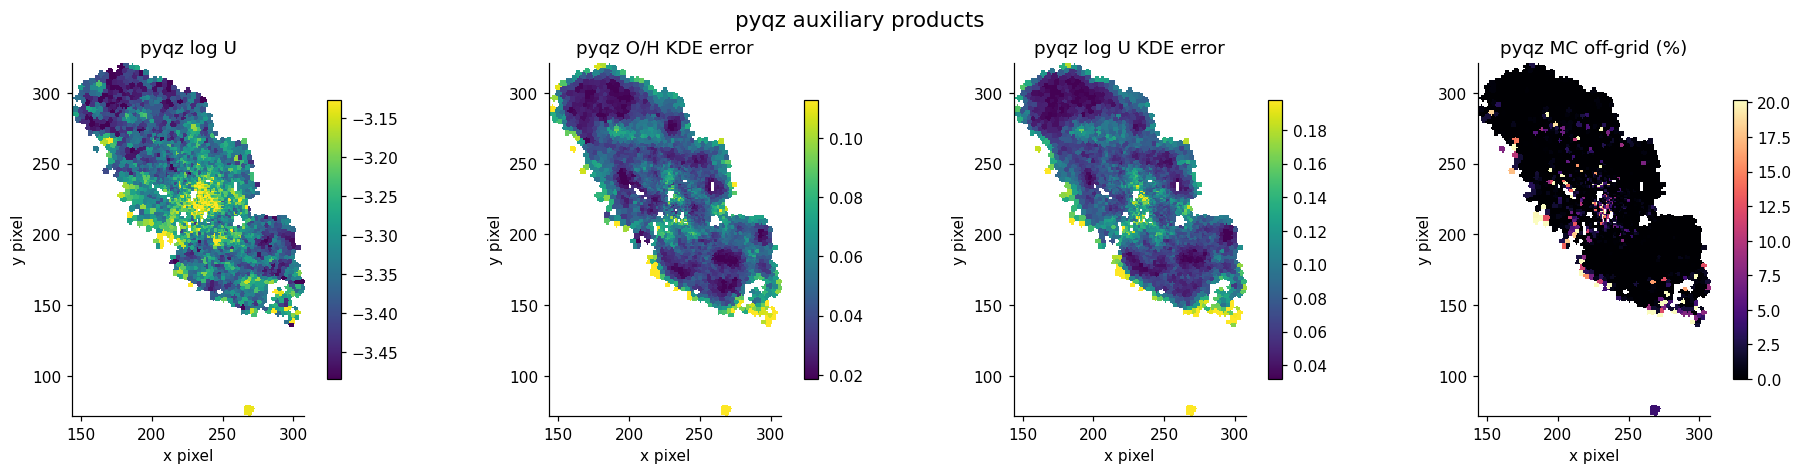

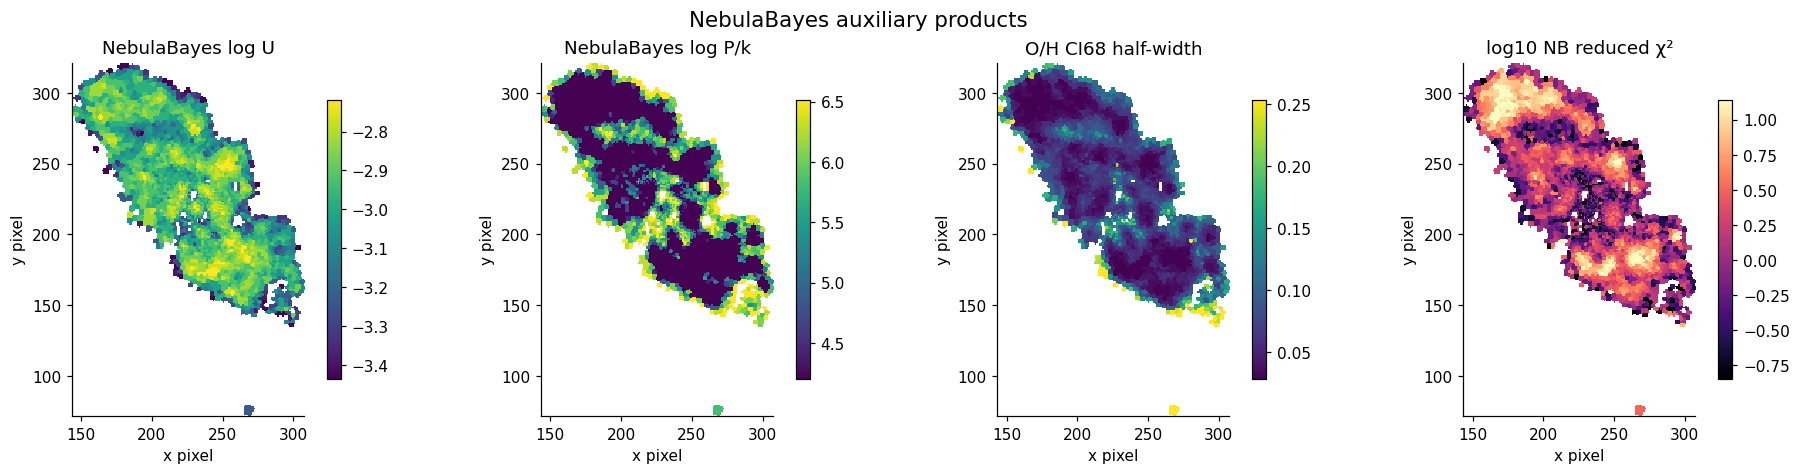

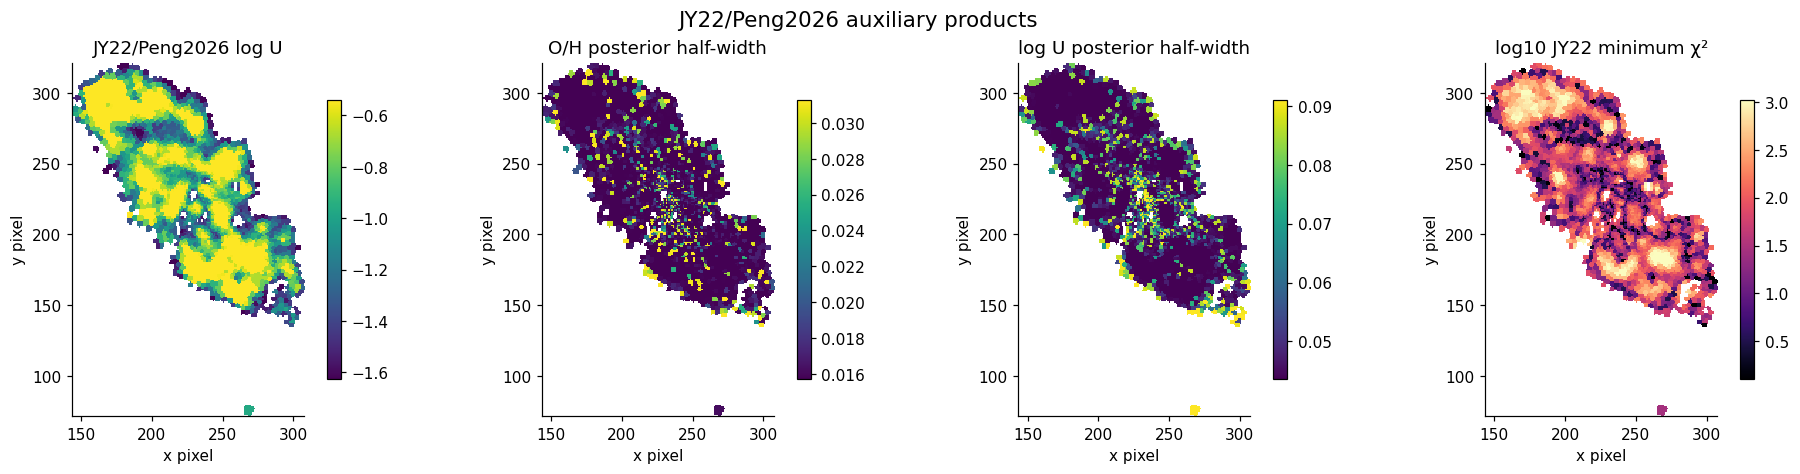

In [9]:
def robust_map(ax, data, title, cmap="viridis", percentile=(2, 98)):
    cropped = np.asarray(data[y_slice, x_slice], float)
    finite = cropped[np.isfinite(cropped)]
    vmin, vmax = np.percentile(finite, percentile)
    if np.isclose(vmin, vmax):
        vmin, vmax = finite.min(), finite.max()
    image = ax.imshow(
        cropped, origin="lower", extent=map_extent, cmap=cmap,
        vmin=vmin, vmax=vmax, interpolation="nearest"
    )
    ax.set_title(title)
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
    plt.colorbar(image, ax=ax, shrink=0.79)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
robust_map(axes[0], maps["LOG_U_PYQZ_HII"], "pyqz log U")
robust_map(axes[1], maps["O_H_PYQZ_HII_ERR"], "pyqz O/H KDE error")
robust_map(axes[2], maps["LOG_U_PYQZ_HII_ERR"], "pyqz log U KDE error")
robust_map(axes[3], maps["PYQZ_RS_OFFGRID_HII"], "pyqz MC off-grid (%)", cmap="magma")
fig.suptitle("pyqz auxiliary products", fontsize=14)
# fig.savefig(ROOT / "20260824_IC3392_pyqz_auxiliary_QC.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
robust_map(axes[0], maps["LOG_U_NEBULABAYES_HII"], "NebulaBayes log U")
robust_map(axes[1], maps["LOG_PK_NEBULABAYES_HII"], "NebulaBayes log P/k")
robust_map(axes[2], 0.5 * (maps["O_H_NEBULABAYES_HII_CI68_HIGH"] - maps["O_H_NEBULABAYES_HII_CI68_LOW"]), "O/H CI68 half-width")
robust_map(axes[3], np.log10(np.where(maps["NB_CHI2_RED_HII"] > 0, maps["NB_CHI2_RED_HII"], np.nan)), "log10 NB reduced χ²", cmap="magma")
fig.suptitle("NebulaBayes auxiliary products", fontsize=14)
# fig.savefig(ROOT / "20260824_IC3392_NebulaBayes_auxiliary_QC.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
robust_map(axes[0], maps["LOG_U_JY22_HII"], "JY22/Peng2026 log U")
robust_map(axes[1], 0.5 * (maps["O_H_JY22_HII_84"] - maps["O_H_JY22_HII_16"]), "O/H posterior half-width")
robust_map(axes[2], 0.5 * (maps["LOG_U_JY22_HII_84"] - maps["LOG_U_JY22_HII_16"]), "log U posterior half-width")
robust_map(axes[3], np.log10(np.where(maps["JY22_CHI2_MIN_HII"] > 0, maps["JY22_CHI2_MIN_HII"], np.nan)), "log10 JY22 minimum χ²", cmap="magma")
fig.suptitle("JY22/Peng2026 auxiliary products", fontsize=14)
# fig.savefig(ROOT / "20260824_IC3392_JY22_auxiliary_QC.png", bbox_inches="tight")
plt.show()

## 5. Reconstruct the JY22 likelihood and inspect the data–model locus

The production likelihood uses dust-corrected N2, S2, and R3 plus their full first-order covariance derived from the six raw line fluxes. Reconstructing it independently from the FITS inputs tests for line-order, covariance, bin-broadcast, and FITS-write mistakes.

Peng et al. select star-forming points using

\[
P_1=0.63N2+0.51S2+0.59R3,\qquad P_2=-0.63N2+0.78S2
\]

and \(P_1 < -1.57P_2^2 + 0.53P_2 - 0.48\). Passing this projection cut is checked separately from obtaining a small three-ratio χ².

In [10]:
WAVELENGTHS_UM = np.asarray([0.4861, 0.5006, 0.6562, 0.6583, 0.6716, 0.6730])

def calzetti_k(wavelength_um):
    wavelength_um = np.asarray(wavelength_um, float)
    output = np.empty_like(wavelength_um)
    short = (wavelength_um >= 0.12) & (wavelength_um < 0.63)
    long = (wavelength_um >= 0.63) & (wavelength_um <= 2.20)
    output[short] = 2.659 * (
        -2.156 + 1.509 / wavelength_um[short]
        - 0.198 / wavelength_um[short] ** 2
        + 0.011 / wavelength_um[short] ** 3
    ) + 4.05
    output[long] = 2.659 * (-1.857 + 1.040 / wavelength_um[long]) + 4.05
    return output

with fits.open(FITS_PATH, memmap=True) as hdul:
    raw_flux_maps = {
        name: np.array(hdul[f"{name}_FLUX"].data, dtype=np.float64, copy=True)
        for name in MODEL_LINE_BASES
    }
    raw_error_maps = {
        name: np.array(hdul[f"{name}_FLUX_ERR"].data, dtype=np.float64, copy=True)
        for name in MODEL_LINE_BASES
    }

raw_spectra = extract_unique_bin_spectra(
    bin_id_map, hii_pixel_mask, raw_flux_maps, raw_error_maps
)
ratio_spectra = build_jy22_ratio_spectra(
    raw_spectra, calzetti_k(WAVELENGTHS_UM), intrinsic_balmer_ratio=2.86
)
assert np.array_equal(ratio_spectra.bin_ids, bin_ids)

released_grid = load_jy22_grid(
    GRID_PATH, min_log_u=-4.0, max_log_u=-0.5, solar_o_h=8.69
)

best_indices = []
best_chi2 = []
best_residual_obs_minus_model = []
best_diag_sigma_residual = []
for observed, covariance in zip(
    ratio_spectra.log_ratios, ratio_spectra.covariances, strict=True
):
    cholesky = np.linalg.cholesky(covariance)
    residual = released_grid.model_ratios - observed
    whitened = np.linalg.solve(cholesky, residual.reshape((-1, 3)).T).T
    chi2 = np.sum(whitened**2, axis=1).reshape(released_grid.model_ratios.shape[:2])
    index = np.unravel_index(np.argmin(chi2), chi2.shape)
    model_at_best = released_grid.model_ratios[index]
    best_indices.append(index)
    best_chi2.append(chi2[index])
    best_residual_obs_minus_model.append(observed - model_at_best)
    best_diag_sigma_residual.append(
        (observed - model_at_best) / np.sqrt(np.diag(covariance))
    )

best_indices = np.asarray(best_indices, int)
best_chi2 = np.asarray(best_chi2, float)
best_residual_obs_minus_model = np.asarray(best_residual_obs_minus_model, float)
best_diag_sigma_residual = np.asarray(best_diag_sigma_residual, float)
stored_chi2 = bin_df["JY22_CHI2_MIN_HII"].to_numpy(float)
chi2_reproduction_max_abs = np.max(np.abs(best_chi2 - stored_chi2))

n2, s2, r3 = ratio_spectra.log_ratios.T
p1 = 0.63 * n2 + 0.51 * s2 + 0.59 * r3
p2 = -0.63 * n2 + 0.78 * s2
peng_sf_selection = p1 < (-1.57 * p2**2 + 0.53 * p2 - 0.48)

ratio_rows = []
for index, name in enumerate(("N2", "S2", "R3")):
    observed = ratio_spectra.log_ratios[:, index]
    model = released_grid.model_ratios[..., index]
    residual = best_residual_obs_minus_model[:, index]
    sigma_residual = best_diag_sigma_residual[:, index]
    ratio_rows.append(
        {
            "ratio": name,
            "obs_p02": np.percentile(observed, 2),
            "obs_median": np.median(observed),
            "obs_p98": np.percentile(observed, 98),
            "model_min": np.min(model),
            "model_max": np.max(model),
            "n_below_global": np.count_nonzero(observed < np.min(model)),
            "n_above_global": np.count_nonzero(observed > np.max(model)),
            "best residual median (obs-model)": np.median(residual),
            "diag-sigma residual median": np.median(sigma_residual),
        }
    )
ratio_qc = pd.DataFrame(ratio_rows).set_index("ratio")

jy22_chi2_percentiles = np.percentile(stored_chi2, [2, 16, 50, 84, 98])
peng_pass_fraction = np.mean(peng_sf_selection)

print(f"Released retained grid shape: {released_grid.model_ratios.shape[:2]}")
print(f"Released retained log-U bounds: {released_grid.effective_log_u_bounds}")
print(f"Maximum |reconstructed - stored minimum chi-square|: {chi2_reproduction_max_abs:.3e}")
print(f"Peng projected SF selection: {peng_sf_selection.sum()}/{peng_sf_selection.size} bins ({peng_pass_fraction:.1%})")
print(f"JY22 chi-square p02,p16,p50,p84,p98: {jy22_chi2_percentiles}")
display(ratio_qc.round(4))

Released retained grid shape: (40, 28)
Released retained log-U bounds: (-4.0, -0.5384615384615388)
Maximum |reconstructed - stored minimum chi-square|: 3.183e-12
Peng projected SF selection: 2375/2404 bins (98.8%)
JY22 chi-square p02,p16,p50,p84,p98: [   1.18921119    7.15200198   54.24978304  221.96508467 1021.3505094 ]


,obs_p02,obs_median,obs_p98,model_min,model_max,n_below_global,n_above_global,best residual median (obs-model),diag-sigma residual median
ratio,,,,,,,,,
N2,-0.7094,-0.5163,-0.3298,-2.9555,-0.3396,0,67,-0.0080,-1.0597
S2,-0.8619,-0.6810,-0.4742,-1.7640,0.0958,0,0,-0.0086,-0.6821
R3,-1.1678,-0.6697,-0.2575,-3.1006,0.6849,0,0,-0.1323,-2.5147


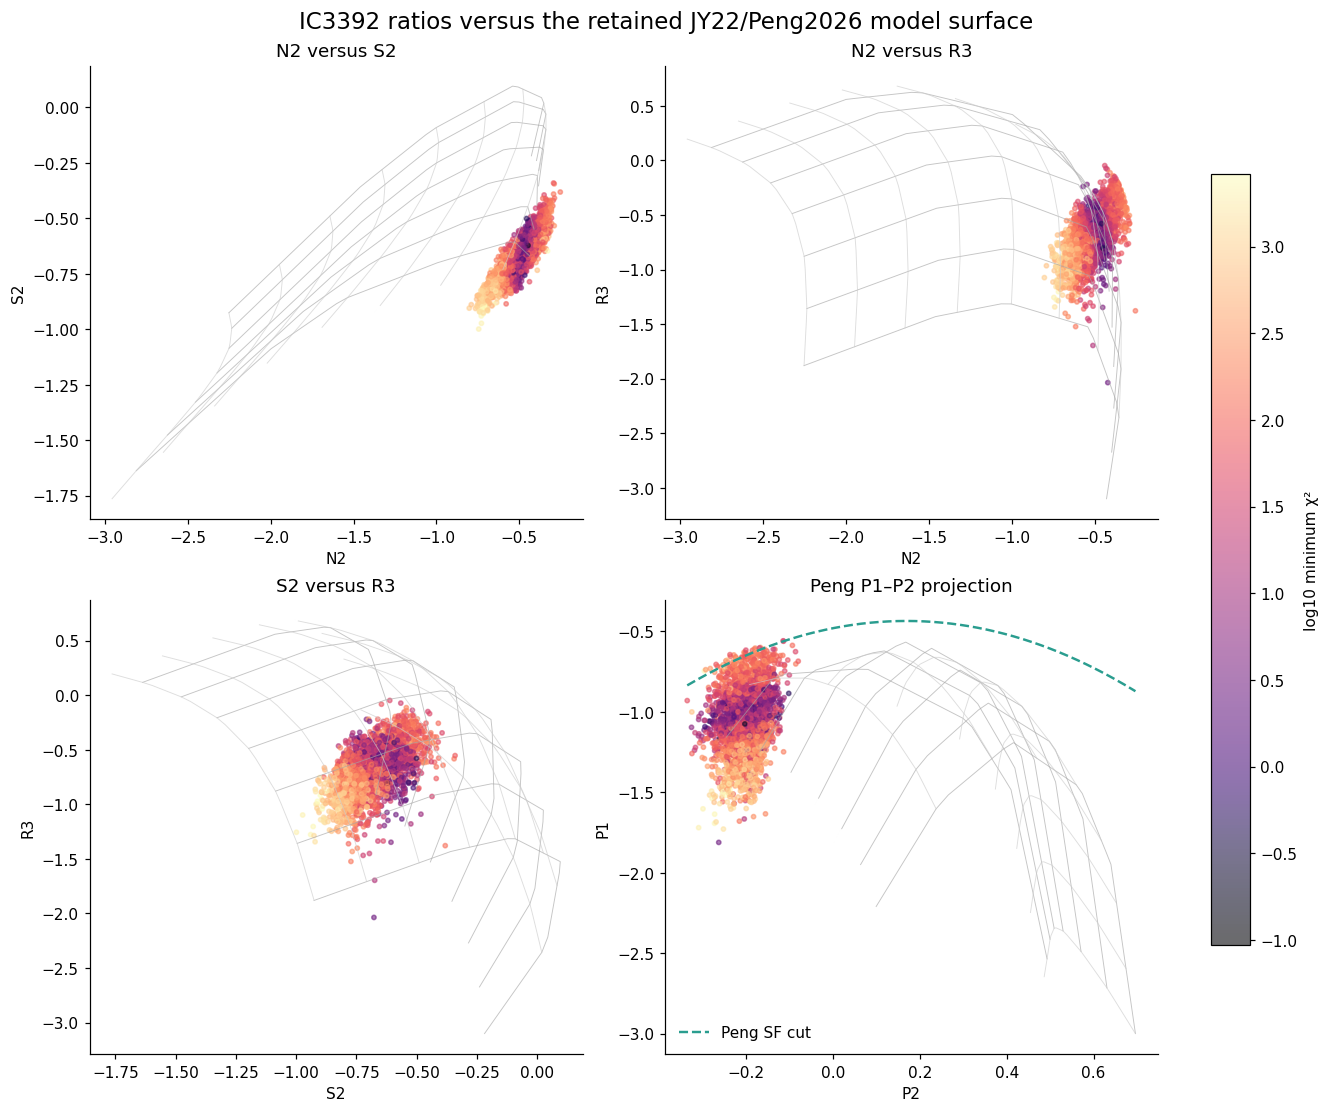

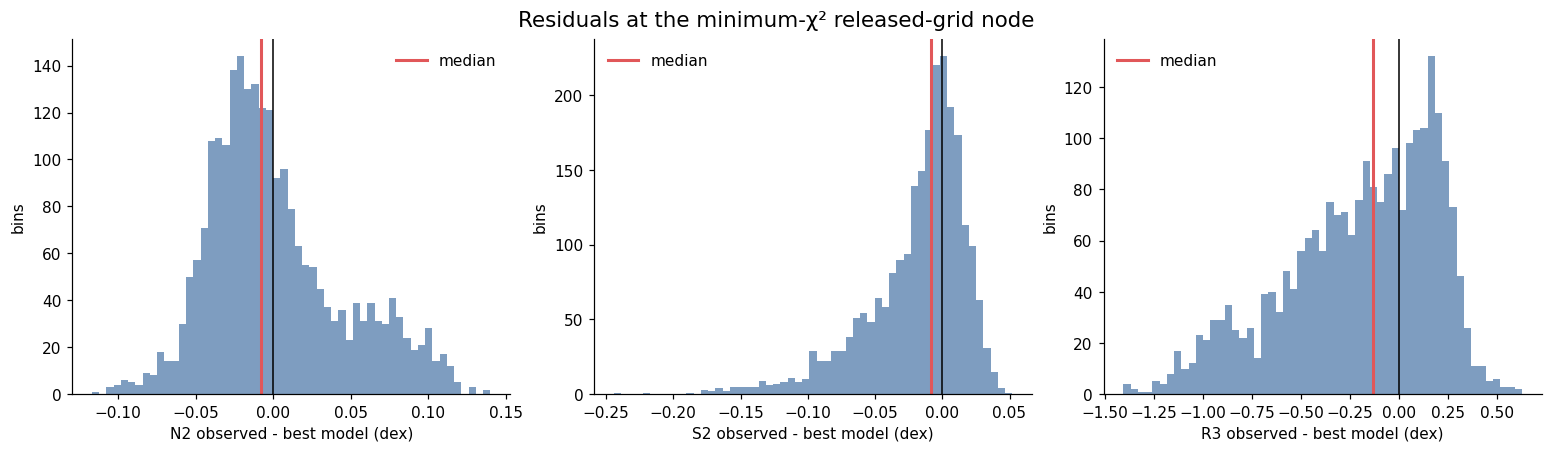

In [11]:
ratio_pairs = ((0, 1, "N2", "S2"), (0, 2, "N2", "R3"), (1, 2, "S2", "R3"))
point_color = np.log10(np.clip(stored_chi2, 1e-3, None))

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, (x_index, y_index, x_label, y_label) in zip(axes.ravel()[:3], ratio_pairs):
    for u_index in range(0, released_grid.log_u.size, 4):
        ax.plot(
            released_grid.model_ratios[:, u_index, x_index],
            released_grid.model_ratios[:, u_index, y_index],
            color="0.65", lw=0.6, alpha=0.65,
        )
    for z_index in range(0, released_grid.o_h.size, 5):
        ax.plot(
            released_grid.model_ratios[z_index, :, x_index],
            released_grid.model_ratios[z_index, :, y_index],
            color="0.80", lw=0.6, alpha=0.65,
        )
    scatter = ax.scatter(
        ratio_spectra.log_ratios[:, x_index], ratio_spectra.log_ratios[:, y_index],
        c=point_color, s=8, cmap="magma", alpha=0.58, rasterized=True,
    )
    ax.set(xlabel=x_label, ylabel=y_label, title=f"{x_label} versus {y_label}")

model_n2, model_s2, model_r3 = np.moveaxis(released_grid.model_ratios, -1, 0)
model_p1 = 0.63 * model_n2 + 0.51 * model_s2 + 0.59 * model_r3
model_p2 = -0.63 * model_n2 + 0.78 * model_s2
ax = axes.ravel()[3]
for u_index in range(0, released_grid.log_u.size, 4):
    ax.plot(model_p2[:, u_index], model_p1[:, u_index], color="0.65", lw=0.6, alpha=0.65)
for z_index in range(0, released_grid.o_h.size, 5):
    ax.plot(model_p2[z_index, :], model_p1[z_index, :], color="0.80", lw=0.6, alpha=0.65)
ax.scatter(p2, p1, c=point_color, s=8, cmap="magma", alpha=0.58, rasterized=True)
p2_curve = np.linspace(min(p2.min(), model_p2.min()), max(p2.max(), model_p2.max()), 300)
ax.plot(p2_curve, -1.57 * p2_curve**2 + 0.53 * p2_curve - 0.48, "--", color="#2A9D8F", lw=1.6, label="Peng SF cut")
ax.set(xlabel="P2", ylabel="P1", title="Peng P1–P2 projection")
ax.legend(frameon=False)

fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.78, label="log10 minimum χ²")
fig.suptitle("IC3392 ratios versus the retained JY22/Peng2026 model surface", fontsize=15)
# fig.savefig(ROOT / "20260824_IC3392_JY22_ratio_locus.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for index, (ax, name) in enumerate(zip(axes, ("N2", "S2", "R3"))):
    ax.hist(best_residual_obs_minus_model[:, index], bins=55, histtype="stepfilled", alpha=0.72, color="#4C78A8")
    ax.axvline(0, color="black", lw=1)
    ax.axvline(np.median(best_residual_obs_minus_model[:, index]), color="#E15759", lw=2, label="median")
    ax.set(xlabel=f"{name} observed - best model (dex)", ylabel="bins")
    ax.legend(frameon=False)
fig.suptitle("Residuals at the minimum-χ² released-grid node", fontsize=14)
# fig.savefig(ROOT / "20260824_IC3392_JY22_best_node_residuals.png", bbox_inches="tight")
plt.show()

## 6. JY22 grid-density and model-error sensitivities

There is a live provenance inconsistency:

- Peng et al. (2026) state that the model is interpolated to **200 × 200** over metallicity and ionisation parameter.
- The downloaded archive README says its **40 × 40** interpolated grid was used in the inference.
- That FITS grid spans log U = −4 to +1. After the pipeline applies the Peng range log U ≤ −0.5, only **40 × 28** nodes remain and the upper retained node is −0.538.

The following controlled sensitivity linearly resamples the released full grid to 200 × 200 over the paper's stated bounds. It changes only numerical sampling, not the underlying photoionisation surface. A second sensitivity adds 0.1 dex independent model scatter to each ratio, following the scale explored by Ji & Yan (2022); this is diagnostic only and is **not** a recommended silent change to the production likelihood.

In [12]:
archive_readme = GRID_README_PATH.read_text(encoding="utf-8")
print(archive_readme)

released_full_grid = load_jy22_grid(
    GRID_PATH, min_log_u=-4.0, max_log_u=1.0, solar_o_h=8.69
)

def resample_jy22_grid(source, n_o_h=200, n_log_u=200):
    o_h = np.linspace(source.o_h[0], source.o_h[-1], n_o_h)
    log_u = np.linspace(-4.0, -0.5, n_log_u)
    o_h_mesh, log_u_mesh = np.meshgrid(o_h, log_u, indexing="ij")
    points = np.column_stack((o_h_mesh.ravel(), log_u_mesh.ravel()))
    model_ratios = np.empty((n_o_h, n_log_u, 3), float)
    for ratio_index in range(3):
        interpolator = RegularGridInterpolator(
            (source.o_h, source.log_u), source.model_ratios[..., ratio_index],
            method="linear", bounds_error=True,
        )
        model_ratios[..., ratio_index] = interpolator(points).reshape(n_o_h, n_log_u)
    return JY22Grid(
        source_path=source.source_path,
        sha256=source.sha256,
        log_z_zsun=o_h - source.solar_o_h,
        o_h=o_h,
        log_u=log_u,
        model_ratios=model_ratios,
        requested_log_u_bounds=(-4.0, -0.5),
        effective_log_u_bounds=(-4.0, -0.5),
        solar_o_h=source.solar_o_h,
    )

paper_density_grid = resample_jy22_grid(released_full_grid, 200, 200)

def evaluate_jy22(grid, ratio_error_floor=0.0):
    extra_covariance = np.eye(3) * ratio_error_floor**2
    records = [
        infer_jy22_posterior(observed, covariance + extra_covariance, grid)
        for observed, covariance in zip(
            ratio_spectra.log_ratios, ratio_spectra.covariances, strict=True
        )
    ]
    return {
        key: np.asarray([record[key] for record in records])
        for key in ("o_h", "log_u", "chi2_min", "flag", "valid")
    }

dense_results = evaluate_jy22(paper_density_grid, ratio_error_floor=0.0)
dense_model_floor_results = evaluate_jy22(paper_density_grid, ratio_error_floor=0.10)

stored_results = {
    "o_h": bin_df["O_H_JY22_HII"].to_numpy(float),
    "log_u": bin_df["LOG_U_JY22_HII"].to_numpy(float),
    "chi2_min": bin_df["JY22_CHI2_MIN_HII"].to_numpy(float),
    "flag": bin_df["JY22_FLAG_HII"].to_numpy(int),
}

def sensitivity_row(label, result):
    flags = np.asarray(result["flag"], int)
    return {
        "case": label,
        "O/H p16": np.percentile(result["o_h"], 16),
        "O/H median": np.median(result["o_h"]),
        "O/H p84": np.percentile(result["o_h"], 84),
        "log U median": np.median(result["log_u"]),
        "chi2 p16": np.percentile(result["chi2_min"], 16),
        "chi2 median": np.median(result["chi2_min"]),
        "chi2 p84": np.percentile(result["chi2_min"], 84),
        "O/H-edge fraction": np.mean((flags & 1) != 0),
        "logU-edge fraction": np.mean((flags & 2) != 0),
    }

sensitivity = pd.DataFrame(
    [
        sensitivity_row("stored released 40x28", stored_results),
        sensitivity_row("paper-density 200x200", dense_results),
        sensitivity_row("200x200 + 0.10 dex ratio model floor", dense_model_floor_results),
    ]
).set_index("case")

dense_delta_oh = dense_results["o_h"] - stored_results["o_h"]
dense_delta_logu = dense_results["log_u"] - stored_results["log_u"]
display(sensitivity.round(4))
print(
    "200x200 minus stored, per-bin median [p16,p84]: "
    f"O/H={np.median(dense_delta_oh):+.4f} "
    f"[{np.percentile(dense_delta_oh,16):+.4f},{np.percentile(dense_delta_oh,84):+.4f}] dex; "
    f"logU={np.median(dense_delta_logu):+.4f} "
    f"[{np.percentile(dense_delta_logu,16):+.4f},{np.percentile(dense_delta_logu,84):+.4f}]"
)

This repository contains the photoionization model grids used in Peng et al. (2026). The grids are based on the photoionization models of Ji & Yan (2020) and generated using CLOUDY C17.03.

photoionization_grid_native.fits
    Native CLOUDY model grid.

photoionization_grid_interpolated.fits
    40 × 40 interpolated grid in the (log Z/Z☉, log U) parameter space used in the Bayesian inference.

Each row corresponds to one photoionization model with:

- log(Z/Zsun)
- log(U)
- log(N/O)

Predicted emission-line intensities and commonly used line ratios are provided.

The CLOUDY input files used to generate the models are also included.

These grids were used throughout the metallicity inference presented in the paper.
200x200 minus stored, per-bin median [p16,p84]: O/H=+0.0006 [-0.0104,+0.0127] dex; logU=+0.0094 [-0.0179,+0.0378]


,O/H p16,O/H median,O/H p84,log U median,chi2 p16,chi2 median,chi2 p84,O/H-edge fraction,logU-edge fraction
case,,,,,,,,,
stored released 40x28,9.0268,9.0870,9.1071,-0.7842,7.1520,54.2498,221.9651,0.0250,0.3557
paper-density 200x200,9.0302,9.0779,9.1172,-0.7596,4.5909,51.0456,209.4825,0.0158,0.2804
200x200 + 0.10 dex ratio model floor,9.0346,9.1192,9.1597,-0.9639,0.0725,0.7688,2.9883,0.1934,0.0408


## 7. Run-log audit

The log is used to distinguish map-level failures from integrated-aperture failures and to retain the exact runtime configuration. Early divide-by-zero warnings are counted but are not by themselves assigned as a cause; their affected pixels are later excluded by finite/model-input masks.

In [13]:
log_text = LOG_PATH.read_text(encoding="utf-8", errors="replace")
log_lines = log_text.splitlines()
warning_count = sum("RuntimeWarning" in line for line in log_lines)

interesting_patterns = (
    "compatibility layer", "pyqz 0.8", "grid identity", "no per-spectrum exceptions",
    "NebulaBayes 0.", "JY22/Peng2026", "JY22 grid:", "integrated HII",
    "integrated SF", "NebulaBayes integrated", "JY22 integrated",
    "  HII:", "  SF:", "    pyqz:", "    NebulaBayes:", "    JY22:",
    "Model covariance note",
)
interesting_lines = [
    f"{index + 1}: {line}"
    for index, line in enumerate(log_lines)
    if any(pattern in line for pattern in interesting_patterns)
]

print(f"Log contains {len(log_lines)} lines and {warning_count} RuntimeWarning entries.")
print("\n".join(interesting_lines))

Log contains 290 lines and 21 RuntimeWarning entries.
110: pyqz/NebulaBayes compatibility layer: model_grid_compat.py
111: pyqz 0.8.4.0: diagnostic=[NII]/[SII]+;[OIII]/[SII]+; Pk=5.0; struct=pp; kappa=inf; sampling=2; srs=800; KDE=multiv; seed=20260823; nproc=1
113: pyqz grid identity: MAPPINGS V HII Region Grid: QZ pp_GCZO_Pk50_kinf
126: pyqz bins: no per-spectrum exceptions
149: NebulaBayes 0.9.9: grid=/arc/home/RongjunHuang/.conda/envs/ICRAR/lib/python3.13/site-packages/NebulaBayes/grids/NB_HII_grid.fits.gz; parameters=['log U', 'log P/k', '12 + log O/H']; shape=(40, 20, 160); order=1; grid_error=0.1; norm=Hbeta; deredden=False; prior=Uniform
162: NebulaBayes bins: no per-spectrum exceptions
163: JY22/Peng2026: ratios=N2,S2,R3; posterior means with marginal equal-tailed p16/p84; full raw-flux ratio covariance; error inflation=1.0
164: JY22 grid: /arc/home/RongjunHuang/ICRAR/further/Peng2026/photoionization_models/photoionization_grid_interpolated.fits; sha256=d7a219b60c9a1ea8b293399

## 8. Evidence-backed interpretation and follow-up priorities

The next cell computes its numerical statements from the live product so that this notebook's conclusion updates if the IC3392 test FITS is replaced and rerun.

In [14]:
pyqz_delta = comparison_to_c20.loc["pyqz", "delta_median"]
pyqz_rho = comparison_to_c20.loc["pyqz", "Spearman_rho"]
nb_delta = comparison_to_c20.loc["NebulaBayes", "delta_median"]
jy_delta_c20 = pair_offsets.loc["JY22 - C20", "median"]
jy_delta_m13 = pair_offsets.loc["JY22 - M13", "median"]
c20_delta_m13 = pair_offsets.loc["C20 - M13", "median"]
jy_rho = comparison_to_c20.loc["JY22/Peng2026", "Spearman_rho"]
jy_slope = comparison_to_c20.loc["JY22/Peng2026", "OLS_slope"]
jy_median_chi2 = np.median(stored_chi2)
jy_logu_edge = jy_flags.loc["log U marginal touches edge", "fraction"]
nb_pressure_edge = nb_flags.loc["log P/k peak at edge", "fraction"]
nb_open_ci = nb_flags.loc["open 68% interval", "fraction"]
dense_per_bin_delta = np.median(dense_delta_oh)
dense_chi2_median = sensitivity.loc["paper-density 200x200", "chi2 median"]
floor_oh_median = sensitivity.loc["200x200 + 0.10 dex ratio model floor", "O/H median"]
floor_chi2_median = sensitivity.loc["200x200 + 0.10 dex ratio model floor", "chi2 median"]

display(
    Markdown(
        f'''### Conclusions

1. **pyqz is the healthiest of the three new abundance products in this IC3392 run.** Its bin-median offset from C20 is {pyqz_delta:+.3f} dex and its spatial rank correlation is ρ={pyqz_rho:.2f}. It has one distinct KDE estimate per valid HII bin rather than a visibly quantized abundance axis. The map-level run reports no per-bin exceptions. The integrated HII pyqz exception and non-finite integrated SF estimate are a separate aperture-level issue that should still be fixed before integrated products are trusted.

2. **NebulaBayes quantization is real, but a denser O/H grid is not the first fix indicated by this test.** The abundance peak occupies {int(node_summary.loc['NebulaBayes O/H peak', 'occupied_values'])} nodes separated by {nb_oh_step:.4f} dex, compared with a median CI68 half-width of {nb_oh_uncertainty:.4f} dex. Its median offset from C20 is {nb_delta:+.3f} dex. More importantly, {nb_pressure_edge:.1%} of HII bins place log(P/k) at a boundary and {nb_open_ci:.1%} have an open 68% interval. The stored marginal **peak** makes the map discrete; pressure range/prior adequacy and the choice of reported estimator should be investigated before merely increasing abundance sampling.

3. **The JY22 high scale cannot be dismissed as the familiar Peng O3N2 comparison.** Peng et al. use O3N2-M13. In IC3392, C20−M13 is {c20_delta_m13:+.3f} dex, JY22−M13 is {jy_delta_m13:+.3f} dex, and JY22−C20 remains {jy_delta_c20:+.3f} dex. The JY22 field also has weak correspondence with C20 (ρ={jy_rho:.2f}, OLS response slope={jy_slope:.2f}). Its robust p98−p02 range is not actually narrower than C20; rather, much of its variation is not the same spatial contrast traced by C20.

4. **The stored JY22 calculation is internally reproducible, but the model likelihood fits IC3392 poorly.** Rebuilding N2/S2/R3 and their full covariance reproduces stored minimum χ² to {chi2_reproduction_max_abs:.1e}. Nevertheless, the bin-median minimum χ² is {jy_median_chi2:.1f}, {jy_logu_edge:.1%} of HII bins touch the log-U edge, and the best model has a median R3 residual of {ratio_qc.loc['R3', 'best residual median (obs-model)']:+.3f} dex. {peng_pass_fraction:.1%} pass the Peng P1–P2 projected SF cut, so that projection alone does not guarantee a good three-ratio likelihood match.

5. **Matching the paper's stated 200×200 numerical density is warranted for provenance, but it does not solve the scientific discrepancy.** The per-bin median O/H shift is only {dense_per_bin_delta:+.4f} dex and the χ² median remains {dense_chi2_median:.1f}. Adding an illustrative 0.10-dex model-ratio floor lowers the χ² median to {floor_chi2_median:.2f}, but leaves median O/H at {floor_oh_median:.3f}; it therefore hides formal tension without reconciling JY22 with C20.

### Prioritised follow-up before a multi-galaxy production run

1. Resolve the **Peng paper (200×200) versus released archive (40×40)** provenance mismatch and make the code/header state the exact evaluation grid. A production change to 200×200 would improve method fidelity, but this IC3392 sensitivity shows it is not the root fix.
2. Add science-readiness QC separate from `VALID`: at minimum propagate JY22 χ² and edge cuts, NebulaBayes pressure/open-CI flags, and pyqz off-grid/flag criteria into downstream selections.
3. Diagnose the JY22 **data–model locus**, especially R3, using representative spectra and independent flux/error checks. Confirm whether the MUSE uncertainties need a documented model-discrepancy term; do not copy the MaNGA-specific 1.25 error inflation or add 0.1 dex silently.
4. For NebulaBayes, test a wider/relevant pressure grid and compare posterior median/mean versus the current marginal peak. Treat a reporting-estimator change as a new product definition, with new HDU names/provenance.
5. Fix or isolate the integrated pyqz failure. Map-level pyqz can proceed to a broader validation sample, but the integrated result should remain excluded.
6. Repeat this exact bin-weighted QC on a small diverse galaxy set before enabling the three new diagnostics for paper analysis. Keep O3N2-C20 primary and show D16, PG16, and M13 as secondary calibration-sensitivity references rather than interchangeable truth.
'''
    )
)

del raw_flux_maps, raw_error_maps
print("QC complete; no science FITS or pipeline files were modified.")

QC complete; no science FITS or pipeline files were modified.


### Conclusions

1. **pyqz is the healthiest of the three new abundance products in this IC3392 run.** Its bin-median offset from C20 is -0.042 dex and its spatial rank correlation is ρ=0.53. It has one distinct KDE estimate per valid HII bin rather than a visibly quantized abundance axis. The map-level run reports no per-bin exceptions. The integrated HII pyqz exception and non-finite integrated SF estimate are a separate aperture-level issue that should still be fixed before integrated products are trusted.

2. **NebulaBayes quantization is real, but a denser O/H grid is not the first fix indicated by this test.** The abundance peak occupies 32 nodes separated by 0.0141 dex, compared with a median CI68 half-width of 0.0635 dex. Its median offset from C20 is +0.106 dex. More importantly, 55.5% of HII bins place log(P/k) at a boundary and 37.1% have an open 68% interval. The stored marginal **peak** makes the map discrete; pressure range/prior adequacy and the choice of reported estimator should be investigated before merely increasing abundance sampling.

3. **The JY22 high scale cannot be dismissed as the familiar Peng O3N2 comparison.** Peng et al. use O3N2-M13. In IC3392, C20−M13 is +0.212 dex, JY22−M13 is +0.517 dex, and JY22−C20 remains +0.304 dex. The JY22 field also has weak correspondence with C20 (ρ=0.09, OLS response slope=0.07). Its robust p98−p02 range is not actually narrower than C20; rather, much of its variation is not the same spatial contrast traced by C20.

4. **The stored JY22 calculation is internally reproducible, but the model likelihood fits IC3392 poorly.** Rebuilding N2/S2/R3 and their full covariance reproduces stored minimum χ² to 3.2e-12. Nevertheless, the bin-median minimum χ² is 54.2, 35.6% of HII bins touch the log-U edge, and the best model has a median R3 residual of -0.132 dex. 98.8% pass the Peng P1–P2 projected SF cut, so that projection alone does not guarantee a good three-ratio likelihood match.

5. **Matching the paper's stated 200×200 numerical density is warranted for provenance, but it does not solve the scientific discrepancy.** The per-bin median O/H shift is only +0.0006 dex and the χ² median remains 51.0. Adding an illustrative 0.10-dex model-ratio floor lowers the χ² median to 0.77, but leaves median O/H at 9.119; it therefore hides formal tension without reconciling JY22 with C20.

### Prioritised follow-up before a multi-galaxy production run

1. Resolve the **Peng paper (200×200) versus released archive (40×40)** provenance mismatch and make the code/header state the exact evaluation grid. A production change to 200×200 would improve method fidelity, but this IC3392 sensitivity shows it is not the root fix.
2. Add science-readiness QC separate from `VALID`: at minimum propagate JY22 χ² and edge cuts, NebulaBayes pressure/open-CI flags, and pyqz off-grid/flag criteria into downstream selections.
3. Diagnose the JY22 **data–model locus**, especially R3, using representative spectra and independent flux/error checks. Confirm whether the MUSE uncertainties need a documented model-discrepancy term; do not copy the MaNGA-specific 1.25 error inflation or add 0.1 dex silently.
4. For NebulaBayes, test a wider/relevant pressure grid and compare posterior median/mean versus the current marginal peak. Treat a reporting-estimator change as a new product definition, with new HDU names/provenance.
5. Fix or isolate the integrated pyqz failure. Map-level pyqz can proceed to a broader validation sample, but the integrated result should remain excluded.
6. Repeat this exact bin-weighted QC on a small diverse galaxy set before enabling the three new diagnostics for paper analysis. Keep O3N2-C20 primary and show D16, PG16, and M13 as secondary calibration-sensitivity references rather than interchangeable truth.
